# Hedging a retail load book

A retailer has promised customers a fixed price and must buy the electricity they use at whatever the market
charges. Its cost is `sum_h price_h * load_h`, uncertain in both factors and, worse, they move together:
cold weather raises load *and* price. This notebook builds the standard hedging toolkit on top of that.

**What's in here**
- A. Minimum-variance hedge with a baseload forward: `beta = cov / var`, hedge effectiveness, adding a peak block via `lstsq`
- B. Volumetric risk: why the optimal hedge is not "buy the expected volume"
- C. Scenario-based CVaR minimisation as an LP (Rockafellar–Uryasev), risk-aversion frontier
- D. Mean-variance with `scipy.optimize.minimize` (SLSQP) and a budget constraint
- Stack hedging over time and a checklist

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog, milp, LinearConstraint, Bounds, minimize
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
df.head(3)

,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh
time,,,,,
2022-01-01 00:00:00+00:00,26858.4,0.11,7.00,0.0,81.83
2022-01-01 01:00:00+00:00,26177.8,-0.18,6.61,0.0,88.21
2022-01-01 02:00:00+00:00,26229.4,-1.11,7.14,0.0,84.71


## The book

The retailer serves 1% of national load. Work in **daily** cost scenarios: 730 days of history, each with 24 hourly
prices and loads. Peak hours are 07:00–19:00 on weekdays (a standard peak block definition).

In [2]:
SHARE = 0.01
d = df.copy()
d["load_mw"] = d["consumption_mwh"] * SHARE
d["cost"] = d["price_eur_mwh"] * d["load_mw"]
d["is_peak"] = (d.index.hour >= 7) & (d.index.hour < 19) & (d.index.dayofweek < 5)
d["date"] = d.index.date

daily = d.groupby("date").agg(cost=("cost", "sum"), load_mwh=("load_mw", "sum"),
                              price_mean=("price_eur_mwh", "mean"), temp=("temp_c", "mean"))
daily["base_sum"] = d.groupby("date")["price_eur_mwh"].sum()                  # sum of 24 hourly prices
daily["peak_sum"] = d[d["is_peak"]].groupby("date")["price_eur_mwh"].sum().reindex(daily.index).fillna(0)
daily["n_peak"] = d.groupby("date")["is_peak"].sum()
daily.index = pd.to_datetime(daily.index)
print("daily cost EUR: mean %.0f  sd %.0f  (%.0f days)" % (daily["cost"].mean(), daily["cost"].std(), len(daily)))
daily.head(3).round(1)

daily cost EUR: mean 714649  sd 210132  (730 days)


,cost,load_mwh,price_mean,temp,base_sum,peak_sum,n_peak
date,,,,,,,
2022-01-01,733746.7,7340.9,98.2,1.8,2358.0,0.0,0
2022-01-02,652123.8,7289.9,87.6,3.2,2101.6,0.0,0
2022-01-03,591348.1,7645.4,75.3,3.4,1807.7,1090.6,12


## A. Minimum-variance hedge with a baseload forward

Buy `Q` MW flat for the day at forward price `F`. The forward pays `Q * sum_h (price_h - F)`, so the hedged
cost is `cost - Q * (base_sum - 24 F)`. `F` is a constant and drops out of the variance, so

`Q* = cov(cost, base_sum) / var(base_sum)`

is a regression slope. Hedge effectiveness `1 - var(hedged) / var(unhedged)` is the R² of that regression.

**Pitfall:** `np.cov` defaults to `ddof=1`, `np.var` to `ddof=0`. Mixing them changes the ratio. Use the same
`ddof` in numerator and denominator, or just use `np.polyfit` / `lstsq`.

In [3]:
C, S = daily["cost"].to_numpy(), daily["base_sum"].to_numpy()
Q_star = np.cov(C, S, ddof=1)[0, 1] / np.var(S, ddof=1)
Q_wrong = np.cov(C, S)[0, 1] / np.var(S)          # ddof mismatch: 1 vs 0
hedged = C - Q_star * (S - S.mean())
eff = 1 - hedged.var() / C.var()
print("Q* = %.1f MW   (ddof-mismatched: %.1f MW, off by n/(n-1))" % (Q_star, Q_wrong))
print("average load = %.1f MW   -> hedge ratio vs volume = %.2f" % (daily["load_mwh"].mean() / 24, Q_star / (daily["load_mwh"].mean() / 24)))
print("hedge effectiveness = %.3f   (sd of daily cost: %.0f -> %.0f EUR)" % (eff, C.std(), hedged.std()))

Q* = 326.8 MW   (ddof-mismatched: 327.3 MW, off by n/(n-1))
average load = 293.2 MW   -> hedge ratio vs volume = 1.11
hedge effectiveness = 0.940   (sd of daily cost: 209988 -> 51413 EUR)


Two things to say out loud: the min-variance hedge is **larger than the expected volume** (the load–price
correlation means you want to be over-hedged in flat terms), and effectiveness measured on the *same* data
used to fit `Q*` is not evidence it will work next year. Fit on 2022, test on 2023:

In [4]:
tr, te = daily.index.year == 2022, daily.index.year == 2023
Q_tr = np.polyfit(S[tr], C[tr], 1)[0]
eff_in = 1 - np.var(C[tr] - Q_tr * S[tr]) / np.var(C[tr])
eff_out = 1 - np.var(C[te] - Q_tr * S[te]) / np.var(C[te])
Q_te = np.polyfit(S[te], C[te], 1)[0]
print("Q fitted on 2022: %.1f MW  |  in-sample eff %.3f  |  2023 out-of-sample eff %.3f  |  Q refit on 2023: %.1f MW" %
      (Q_tr, eff_in, eff_out, Q_te))

Q fitted on 2022: 315.9 MW  |  in-sample eff 0.879  |  2023 out-of-sample eff 0.962  |  Q refit on 2023: 366.9 MW


Here the out-of-sample figure happens to be *higher* (2023 prices were calmer, so a fixed hedge explained more),
but the refitted hedge ratio moves from 316 to 367 MW: the hedge ratio itself is regime-dependent, which is the
real risk. Report both the out-of-sample effectiveness and the stability of `Q`.

### Adding a peak block

Load is higher in peak hours, so a flat hedge leaves shape risk. With two instruments the min-variance hedge is a
two-variable regression: `cost ≈ a + q_b * base_sum + q_p * peak_sum`. Solve with `np.linalg.lstsq`
(add a column of ones for the intercept).

**Interview check:** "why is `q_b` lower now?" Because the peak block takes over the daytime volume; the two
hedges are collinear (`peak_sum` is part of `base_sum`), so read them together, not one by one.

In [5]:
X2 = np.column_stack([np.ones(len(daily)), S, daily["peak_sum"].to_numpy()])
coef, *_ = np.linalg.lstsq(X2, C, rcond=None)
resid2 = C - X2 @ coef
print("q_base = %.1f MW, q_peak = %.1f MW (on top of base in peak hours)" % (coef[1], coef[2]))
print("effectiveness: baseload only %.3f  ->  base + peak %.3f" % (eff, 1 - resid2.var() / C.var()))
print("corr(base_sum, peak_sum) = %.3f" % np.corrcoef(S, daily["peak_sum"])[0, 1])

q_base = 307.1 MW, q_peak = 36.3 MW (on top of base in peak hours)
effectiveness: baseload only 0.940  ->  base + peak 0.949
corr(base_sum, peak_sum) = 0.521


## B. Volumetric risk

`E[price * load] = E[price] E[load] + cov(price, load)`. The covariance term is cost you pay *on average*
because you consume more exactly when it is expensive; no fixed-volume hedge removes it. And hedging the
expected volume leaves a residual `(load - Q) * price` that is large in cold, expensive hours.

In [6]:
p, L = d["price_eur_mwh"].to_numpy(), d["load_mw"].to_numpy()
cov_term = np.cov(p, L, ddof=0)[0, 1]
print("hourly: E[p]E[L] = %.0f   cov(p,L) = %.0f   -> covariance is %.1f%% of expected hourly cost" %
      (p.mean() * L.mean(), cov_term, 100 * cov_term / (p.mean() * L.mean())))
print("corr(price, load) hourly = %.2f ; daily = %.2f" % (np.corrcoef(p, L)[0, 1], daily[["price_mean", "load_mwh"]].corr().iloc[0, 1]))

Q_vol = L.mean()                                        # "hedge the expected volume"
resid_vol = (L - Q_vol) * p                             # hourly residual exposure
print("sd of daily residual cost, hedging expected volume: %.0f EUR  vs min-variance hedge: %.0f EUR" %
      (pd.Series(resid_vol, index=d.index).resample("D").sum().std(), hedged.std()))
cold = d["temp_c"] < d["temp_c"].quantile(0.05)
print("mean residual exposure per hour: cold 5%% of hours %.0f EUR  |  other hours %.0f EUR" %
      (resid_vol[cold].mean(), resid_vol[~cold].mean()))

hourly: E[p]E[L] = 28883   cov(p,L) = 894   -> covariance is 3.1% of expected hourly cost
corr(price, load) hourly = 0.58 ; daily = 0.45
sd of daily residual cost, hedging expected volume: 55571 EUR  vs min-variance hedge: 51413 EUR
mean residual exposure per hour: cold 5% of hours 1475 EUR  |  other hours 864 EUR


## C. CVaR minimisation as an LP

Variance punishes good and bad surprises alike. Retail desks care about the **tail**: the cost in the worst
5% of scenarios. `CVaR_95` (expected cost in the worst 5%) has a linear representation
(Rockafellar & Uryasev, 2000):

`CVaR_a(C) = min_t  t + 1/((1-a) K) * sum_k max(C_k - t, 0)`

so with auxiliary `z_k >= C_k - t`, `z_k >= 0` the whole problem `min E[C] + lambda * CVaR` is an LP in
`(q_base, q_peak, t, z_1..z_K)` as long as `C_k` is linear in the decisions, which it is.

### Scenarios
Block-bootstrap whole days (keeps the 24-hour shape) and add a shared shock so that load and price move together
beyond what the sampled day already contains: cold snaps raise load by ~5% per sd and price by ~10% per sd.

In [7]:
rng = np.random.default_rng(42)
K, ALPHA = 500, 0.95
day_index = d.groupby("date").indices                              # date -> row positions
dates = list(day_index.keys())
sampled = rng.choice(len(dates), K)
shock = rng.normal(0, 1, K)

price_s = np.stack([p[day_index[dates[i]]] for i in sampled]) * (1 + 0.10 * shock)[:, None]   # (K, 24)
load_s = np.stack([L[day_index[dates[i]]] for i in sampled]) * (1 + 0.05 * shock)[:, None]
peak_s = np.stack([d["is_peak"].to_numpy()[day_index[dates[i]]] for i in sampled])           # (K, 24) bool

F_base = price_s.mean() * 1.02                       # forward prices carry a small premium over expected spot
F_peak = price_s[peak_s].mean() * 1.02
unhedged = (price_s * load_s).sum(axis=1)            # a_k
B = (price_s - F_base).sum(axis=1)                   # payoff per MW of baseload
Pk = ((price_s - F_peak) * peak_s).sum(axis=1)       # payoff per MW of peak block
w = np.full(K, 1 / K)                                 # scenario probabilities (must sum to 1)
print("unhedged daily cost: mean %.0f  sd %.0f  CVaR95 %.0f" %
      (unhedged.mean(), unhedged.std(), np.sort(unhedged)[int(ALPHA * K):].mean()))
print("expected forward payoff per MW: base %.1f  peak %.1f  (negative = premium paid)" % (B.mean(), Pk.mean()))

unhedged daily cost: mean 714613  sd 249002  CVaR95 1251213
expected forward payoff per MW: base -47.0  peak -19.2  (negative = premium paid)


### Building the LP

Variables `x = [q_b, q_p, t, z_1..z_K]`. Hedged cost `C_k = a_k - q_b B_k - q_p P_k`.

- objective: `sum_k w_k a_k - q_b sum w_k B_k - q_p sum w_k P_k + lambda * (t + 1/(1-a) sum_k w_k z_k)`
- constraints `z_k >= C_k - t`  →  `-q_b B_k - q_p P_k - t - z_k <= -a_k`
- bounds: `q >= 0` (we only buy), `t` **free**, `z >= 0`

**Pitfall:** `t` (the VaR level) must be unbounded below and above. Leaving the default `(0, None)` is a silent
bug when costs can be negative (or, for a P&L formulation, when you flip the sign).

In [8]:
def cvar_hedge_lp(a, B, Pk, w, lam, alpha=ALPHA, q_max=None):
    K = len(a)
    c = np.concatenate([[-(w * B).sum(), -(w * Pk).sum(), lam], lam * w / (1 - alpha)])
    A_ub = np.column_stack([-B, -Pk, -np.ones(K), -np.eye(K)])
    b_ub = -a
    bounds = [(0, q_max), (0, q_max), (None, None)] + [(0, None)] * K
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    assert res.status == 0, res.message
    q_b, q_p, t = res.x[:3]
    hedged = a - q_b * B - q_p * Pk
    n_tail = int(round((1 - alpha) * K))           # worst 5% of scenarios
    tail = np.sort(hedged)[-n_tail:]
    var_, cvar = tail[0], tail.mean()
    return dict(lam=lam, q_base=q_b, q_peak=q_p, exp_cost=(w * hedged).sum(), sd=hedged.std(),
                VaR95=var_, CVaR95=cvar, t=t, obj=res.fun + (w * a).sum())

rows = [cvar_hedge_lp(unhedged, B, Pk, w, lam) for lam in [0, 0.25, 0.5, 1, 2, 5, 20]]
frontier = pd.DataFrame(rows).set_index("lam")
frontier.round(1)

,q_base,q_peak,exp_cost,sd,VaR95,CVaR95,t,obj
lam,,,,,,,,
0.00,0.0,0.0,714613.1,249002.2,1131943.2,1251213.4,1653082.9,714613.1
0.25,370.4,28.0,732565.7,66581.5,825350.3,847978.6,825350.3,944560.4
0.50,371.7,29.7,732658.3,67044.0,827226.3,847696.7,827226.3,1156506.6
1.00,372.0,29.5,732667.2,67099.7,827407.7,847685.1,827407.7,1580352.2
2.00,371.3,33.3,732708.4,67236.3,826408.0,847659.2,826408.0,2428026.9
5.00,371.3,33.3,732708.4,67236.3,826408.0,847659.2,826408.0,4971004.6
20.00,371.1,34.6,732724.5,67297.2,826137.3,847657.4,826137.3,17685872.8


Reading the table: at `lambda = 0` the desk minimises expected cost only and buys nothing, because the forward
carries a premium. As soon as `lambda` is positive the tail dominates and the hedge jumps to about 370 MW baseload
plus 30 MW peak, cutting CVaR95 by roughly a third for ~2.5% more expected cost. Beyond that, more risk aversion
barely changes the position: the remaining tail is volume risk that no fixed-volume forward can remove.
Note `t` equals `VaR95`: that is the RU construction working as designed.

**Interview check:** "how would you pick lambda?" From a risk budget: the largest CVaR the business can tolerate,
then read the cheapest hedge off the frontier. `lambda` is a dial, not a parameter to estimate.

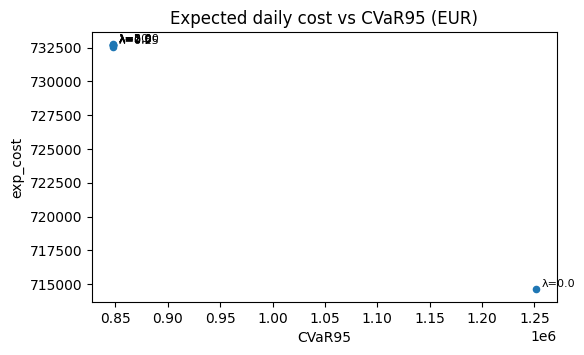

In [9]:
ax = frontier.plot.scatter(x="CVaR95", y="exp_cost", figsize=(6, 3.5))
for lam, r in frontier.iterrows():
    ax.annotate(f"λ={lam}", (r["CVaR95"], r["exp_cost"]), fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.set_title("Expected daily cost vs CVaR95 (EUR)"); plt.show()

### Check the LP against a direct computation

The optimiser's `t` should equal the empirical VaR and its objective the empirical CVaR of the hedged
distribution. If they do not agree the constraint matrix is wrong, not the solver.

In [10]:
r1 = frontier.loc[1.0]
print("t from LP %.0f  vs empirical VaR95 %.0f" % (r1["t"], r1["VaR95"]))
print("objective %.0f  vs E[C] + 1*CVaR95 = %.0f" % (r1["obj"], r1["exp_cost"] + r1["CVaR95"]))
assert abs(r1["obj"] - (r1["exp_cost"] + r1["CVaR95"])) < 1.0

t from LP 827408  vs empirical VaR95 827408
objective 1580352  vs E[C] + 1*CVaR95 = 1580352


## D. Mean-variance with `scipy.optimize.minimize`

For a non-linear objective use `minimize`. The API: `fun(x)`, a starting point `x0`, `bounds`, and
`constraints` as dicts with `type` in `{"eq", "ineq"}` where `"ineq"` means `fun(x) >= 0`. SLSQP handles bounds
and constraints; always check `res.success` and try a second `x0`.

Here: minimise `E[C] + kappa * Var(C) / sd(C_unhedged)` (the division puts both terms in EUR, see the pitfall below)
subject to a hedge budget: the expected premium paid may not exceed a cap.

In [11]:
def hedged_cost(q):
    return unhedged - q[0] * B - q[1] * Pk

SD0 = unhedged.std()
def objective(q, kappa=1.0):
    hc = hedged_cost(q)
    return hc.mean() + kappa * hc.var() / SD0          # both terms in EUR

premium_per_mw = np.array([-B.mean(), -Pk.mean()])    # expected cost of holding 1 MW of each
BUDGET = 8000.0                                         # EUR/day of premium we are willing to pay
cons = [{"type": "ineq", "fun": lambda q: BUDGET - premium_per_mw @ q}]     # >= 0

res_mv = minimize(objective, x0=np.array([100.0, 0.0]), method="SLSQP", bounds=[(0, None), (0, None)], constraints=cons)
res_mv2 = minimize(objective, x0=np.array([0.0, 300.0]), method="SLSQP", bounds=[(0, None), (0, None)], constraints=cons)
print(res_mv.success, res_mv.message, " q =", res_mv.x.round(1), " obj %.0f" % res_mv.fun)
print(res_mv2.success, " from another start q =", res_mv2.x.round(1), " obj %.0f" % res_mv2.fun)
print("premium spent %.0f of budget %.0f" % (premium_per_mw @ res_mv.x, BUDGET))
res_unc = minimize(objective, x0=np.array([100.0, 0.0]), method="SLSQP", bounds=[(0, None), (0, None)])
print("without the budget constraint: q =", res_unc.x.round(1), " premium %.0f" % (premium_per_mw @ res_unc.x))

True Optimization terminated successfully  q = [170.1   0. ]  obj 798406
True  from another start q = [170.1   0. ]  obj 798406
premium spent 8000 of budget 8000
without the budget constraint: q = [322.6  32. ]  premium 15783


**Pitfall:** a raw `mean + kappa * var` objective mixes EUR with EUR²: the variance term is ~1e10 while the mean is
~1e5, `kappa` has units of 1/EUR, and SLSQP reports "positive directional derivative in linesearch" from some starting
points. Rescale so both terms have the same units (as above). Two different starting points agreeing is the minimum
convergence check; `res.success` alone is not enough.

## Stack hedging in practice

Nobody hedges a month once. Load forecasts sharpen as delivery approaches, so the hedge is built up in steps
("a hedging stack"): a fraction of expected volume is bought at each horizon, and the last slice is adjusted
in the day-ahead and intraday markets. The table is the policy; the numbers above tell you what the final
hedge should look like.

In [12]:
stack = pd.DataFrame({
    "months_to_delivery": [24, 12, 6, 3, 1, 0],
    "target_hedge_pct": [20, 40, 60, 80, 95, 100],
    "instrument": ["season baseload", "quarter baseload", "month baseload", "month base + peak", "week/month shape", "day-ahead / intraday"],
    "forecast_uncertainty_pct": [15, 12, 8, 5, 3, 1],
}).set_index("months_to_delivery")
stack

,target_hedge_pct,instrument,forecast_uncertainty_pct
months_to_delivery,,,
24,20,season baseload,15
12,40,quarter baseload,12
6,60,month baseload,8
3,80,month base + peak,5
1,95,week/month shape,3
0,100,day-ahead / intraday,1


## Checklist

1. Write cost as `sum price × load`; the covariance term is real cost, not noise.
2. Min-variance hedge ratio is a regression slope; keep `ddof` consistent or use `polyfit`/`lstsq`.
3. Report hedge effectiveness **out of sample**; in-sample R² on the fitting data is optimistic.
4. Expect the flat hedge to exceed expected volume when price and load are positively correlated.
5. Add shape instruments (peak) when the load profile is not flat; read collinear hedge coefficients jointly.
6. CVaR is an LP: scenario probabilities sum to 1, `t` is free, `z >= 0`; verify `t ≈ VaR` and objective ≈ E + λCVaR.
7. `lambda` is a risk budget dial, chosen by the business, not estimated.
8. For `minimize`: check `res.success`, rerun from another `x0`, rescale terms of very different magnitude.
9. Hedging is a policy over time (stack), not a single number.